# Machine Learning

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [2]:
X_train = joblib.load("../models/X_train_engineered_processed.pkl")
X_test = joblib.load("../models/X_test_engineered_processed.pkl")
y_train = joblib.load("../models/y_train.pkl")
y_test = joblib.load("../models/y_test.pkl")

In [3]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 75)
X_test : (1409, 75)
y_train: (5634,)
y_test : (1409,)


In [4]:
results = []

In [5]:
def evaluate_model(
    model_name,
    model,
    y_test,
    y_pred,
    y_proba,
    training_time
):
    
    y_test_binary = (y_test == "Yes").astype(int)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test,y_pred,pos_label="Yes",zero_division=0),
        "Recall": recall_score(y_test,y_pred,pos_label="Yes",zero_division=0),
        "F1-Score": f1_score(y_test,y_pred,pos_label="Yes",zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_binary,y_proba),
        "PR-AUC": average_precision_score(y_test_binary,y_proba),
        "Training Time (sec)": training_time
    })

## Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression
import time

In [7]:
logistic_model = LogisticRegression(class_weight="balanced",max_iter=1000,random_state=42)

In [8]:
start_time = time.time()

logistic_model.fit(
    X_train,
    y_train
)

training_time = time.time() - start_time

In [9]:
y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:, 1]
evaluate_model(
    "Logistic Regression",
    logistic_model,
    y_test,
    y_pred,
    y_proba,
    training_time
)

In [10]:
results_df = pd.DataFrame(results)
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC",
    "Training Time (sec)"
]

results_df[metric_columns] = results_df[metric_columns].round(4)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time (sec)
0,Logistic Regression,0.7367,0.5026,0.7861,0.6131,0.8404,0.6299,0.4617


## Decision Tree 

In [11]:
from sklearn.tree import DecisionTreeClassifier

In [12]:
decision_tree = DecisionTreeClassifier(
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

In [13]:
start_time = time.time()
decision_tree.fit(
    X_train,
    y_train
)
training_time = time.time() - start_time

In [14]:
y_pred = decision_tree.predict(X_test)

y_proba = decision_tree.predict_proba(X_test)[:, 1]
evaluate_model(
    "Decision Tree",
    decision_tree,
    y_test,
    y_pred,
    y_proba,
    training_time
)

In [15]:
results_df = pd.DataFrame(results)
results_df[metric_columns] = (results_df[metric_columns].round(4))
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time (sec)
0,Logistic Regression,0.7367,0.5026,0.7861,0.6131,0.8404,0.6299,0.4617
1,Decision Tree,0.7268,0.4909,0.7941,0.6067,0.8218,0.6148,0.1378


## KNN 

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [17]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [18]:
start_time = time.time()
knn_model.fit(
    X_train,
    y_train
)
training_time = time.time() - start_time

In [19]:
y_pred = knn_model.predict(X_test)

y_proba = knn_model.predict_proba(X_test)[:, 1]
evaluate_model(
    "KNN",
    knn_model,
    y_test,
    y_pred,
    y_proba,
    training_time
)

In [20]:
results_df = pd.DataFrame(results)
results_df[metric_columns] = (results_df[metric_columns].round(4))
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time (sec)
0,Logistic Regression,0.7367,0.5026,0.7861,0.6131,0.8404,0.6299,0.4617
1,Decision Tree,0.7268,0.4909,0.7941,0.6067,0.8218,0.6148,0.1378
2,KNN,0.7679,0.5685,0.5214,0.5439,0.7910,0.5312,0.0280


## Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [23]:
start_time = time.time()
random_forest.fit(
    X_train,
    y_train
)
training_time = time.time() - start_time

In [24]:
y_pred = random_forest.predict(X_test)
y_proba = random_forest.predict_proba(X_test)[:, 1]
evaluate_model(
    "Random Forest",
    random_forest,
    y_test,
    y_pred,
    y_proba,
    training_time
)

In [25]:
results_df = pd.DataFrame(results)
results_df[metric_columns] = (results_df[metric_columns].round(4))
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time (sec)
0,Logistic Regression,0.7367,0.5026,0.7861,0.6131,0.8404,0.6299,0.4617
1,Decision Tree,0.7268,0.4909,0.7941,0.6067,0.8218,0.6148,0.1378
2,KNN,0.7679,0.5685,0.5214,0.5439,0.7910,0.5312,0.0280
3,Random Forest,0.7573,0.5296,0.7647,0.6258,0.8389,0.6431,1.6990


## Gradient Boosting

In [26]:
from sklearn.ensemble import GradientBoostingClassifier

In [27]:
gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [28]:
start_time = time.time()
gradient_boosting.fit(
    X_train,
    y_train
)
training_time = time.time() - start_time

In [29]:
y_pred = gradient_boosting.predict(X_test)
y_proba = gradient_boosting.predict_proba(X_test)[:, 1]
evaluate_model(
    "Gradient Boosting",
    gradient_boosting,
    y_test,
    y_pred,
    y_proba,
    training_time
)

In [30]:
results_df = pd.DataFrame(results)
results_df[metric_columns] = (results_df[metric_columns].round(4))
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time (sec)
0,Logistic Regression,0.7367,0.5026,0.7861,0.6131,0.8404,0.6299,0.4617
1,Decision Tree,0.7268,0.4909,0.7941,0.6067,0.8218,0.6148,0.1378
2,KNN,0.7679,0.5685,0.5214,0.5439,0.7910,0.5312,0.0280
3,Random Forest,0.7573,0.5296,0.7647,0.6258,0.8389,0.6431,1.6990
4,Gradient Boosting,0.8048,0.6701,0.5214,0.5865,0.8444,0.6560,5.3461


## XGBoost

In [31]:
from xgboost import XGBClassifier

In [32]:
y_train_xgb = (y_train == "Yes").astype(int)
y_test_xgb = (y_test == "Yes").astype(int)

In [33]:
print(y_train_xgb.value_counts())
print(y_test_xgb.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64
Churn
0    1035
1     374
Name: count, dtype: int64


In [34]:
negative_count = (y_train_xgb == 0).sum()
positive_count = (y_train_xgb == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative class:", negative_count)
print("Positive class:", positive_count)
print("Scale pos weight:", scale_pos_weight)

Negative class: 4139
Positive class: 1495
Scale pos weight: 2.768561872909699


In [35]:
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [36]:
start_time = time.time()
xgb_model.fit(
    X_train,
    y_train_xgb
)
training_time = time.time() - start_time

In [37]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]


In [38]:
y_pred_xgb_labels = np.where(y_pred_xgb == 1,"Yes","No")

In [39]:
print(np.unique(y_pred_xgb_labels))

['No' 'Yes']


In [40]:
evaluate_model(
    "XGBoost",
    xgb_model,
    y_test,
    y_pred_xgb_labels,
    y_proba_xgb,
    training_time
)

In [41]:
results_df = pd.DataFrame(results)
results_df[metric_columns] = (results_df[metric_columns].round(4))
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time (sec)
0,Logistic Regression,0.7367,0.5026,0.7861,0.6131,0.8404,0.6299,0.4617
1,Decision Tree,0.7268,0.4909,0.7941,0.6067,0.8218,0.6148,0.1378
2,KNN,0.7679,0.5685,0.5214,0.5439,0.7910,0.5312,0.0280
3,Random Forest,0.7573,0.5296,0.7647,0.6258,0.8389,0.6431,1.6990
4,Gradient Boosting,0.8048,0.6701,0.5214,0.5865,0.8444,0.6560,5.3461
5,XGBoost,0.7566,0.5273,0.7995,0.6355,0.8466,0.6604,1.0266


## Confusion Matrix

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(model_name, y_true, y_pred):
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=["No", "Yes"],
        display_labels=["No", "Yes"]
    )
    
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

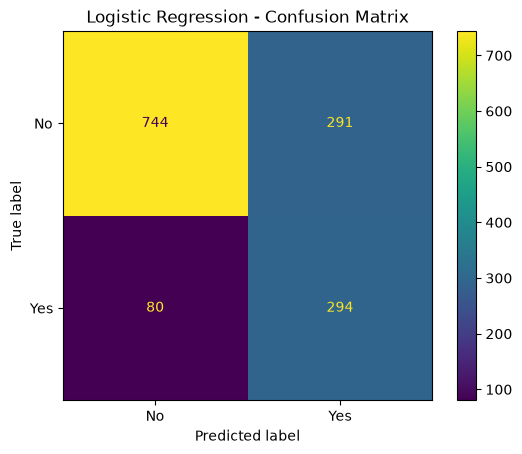

In [43]:
plot_confusion_matrix("Logistic Regression",y_test,logistic_model.predict(X_test))

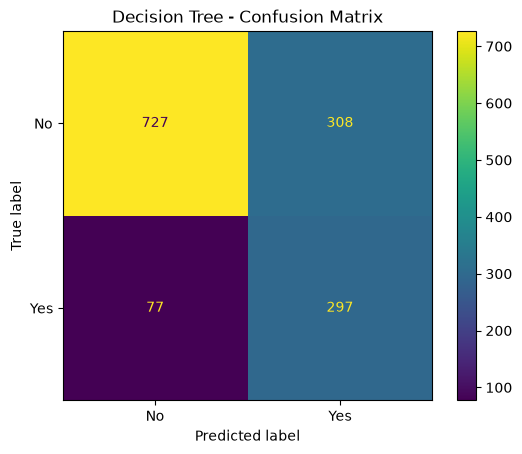

In [44]:
plot_confusion_matrix("Decision Tree",y_test,decision_tree.predict(X_test))

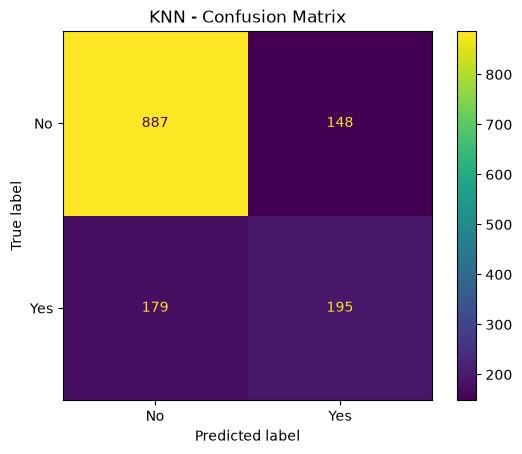

In [45]:
plot_confusion_matrix("KNN",y_test,knn_model.predict(X_test))

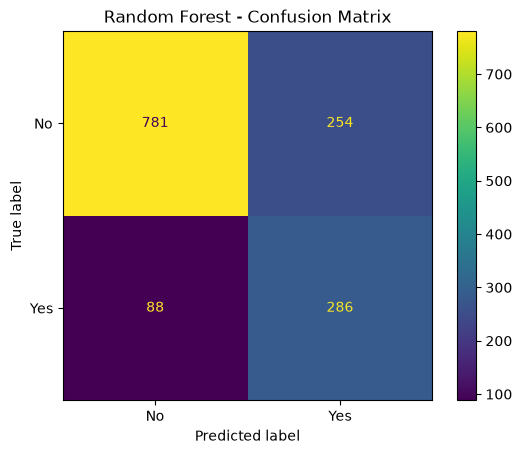

In [46]:
plot_confusion_matrix("Random Forest",y_test,random_forest.predict(X_test))

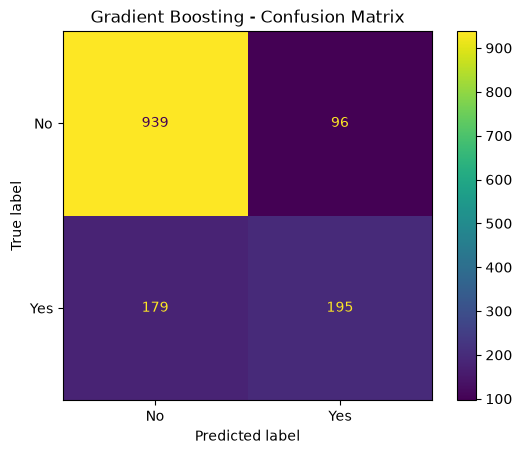

In [47]:
plot_confusion_matrix("Gradient Boosting",y_test,gradient_boosting.predict(X_test))

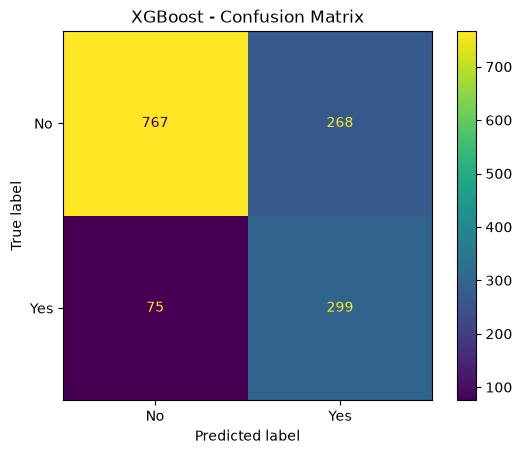

In [48]:
xgb_pred_labels = np.where(xgb_model.predict(X_test) == 1,"Yes","No")
plot_confusion_matrix("XGBoost",y_test,xgb_pred_labels)

## Classification report

In [49]:
from sklearn.metrics import classification_report
print(classification_report(
        y_test,
        logistic_model.predict(X_test),
        target_names=["No", "Yes"]
    )
)

              precision    recall  f1-score   support

          No       0.90      0.72      0.80      1035
         Yes       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [50]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-Score",ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time (sec)
0,XGBoost,0.756565,0.527337,0.799465,0.635494,0.846594,0.660382,1.026624
1,Random Forest,0.757275,0.529630,0.764706,0.625821,0.838903,0.643058,1.699015
2,Logistic Regression,0.736693,0.502564,0.786096,0.613139,0.840378,0.629892,0.461660
3,Decision Tree,0.726757,0.490909,0.794118,0.606742,0.821822,0.614773,0.137753
4,Gradient Boosting,0.804826,0.670103,0.521390,0.586466,0.844385,0.656003,5.346065
5,KNN,0.767921,0.568513,0.521390,0.543933,0.791043,0.531229,0.027988


In [51]:
results_df.to_csv(
    "../models/phase5_baseline_model_results.csv",
    index=False
)